# Fundamental analysis of US Stock Market
In this notebook I carry out fundamental analysis of companies from the [S&P 500 Index](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies) using their annual financial reporting as made available by Yahoo-Finance with the help of the [yfinance](https://pypi.org/project/yfinance/) library. Specifically I look at:
* the market capitalization of listed companies that are members of the S&P 500
* their effective tax rate
* their return on invested capital (ROIC), and its variant called recurring return on invested capital (Recurring ROIC)
* their return on equity
* their cost of equity
* their after tax cost of debt
* their weighted average cost of capital (WACC)
* their enterprise value added (EVA)
* their market value added (MVA)

I calculate these metrics as follows:
$$\text{Effective tax rate} = \frac{\text{Tax Provision}}{\text{Pretax Income}}$$
$$\text{NOPAT} = \text{Net Income} + \text{Net Interest} \times (1 - \text{Effective tax rate})$$
$$\text{Recurring NOPAT} = \text{NOPAT} + \text{Non recurring items} \times (1 - \text{Effective tax rate})$$
$$\text{Invested Capital} = \text{Total Equity} + \text{Net Debt}$$
$$\text{ROIC} = \frac{\text{NOPAT}}{\text{Invested Capital}}$$
$$\text{Recurring ROIC} = \frac{\text{Recurring NOPAT}}{\text{Invested Capital}}$$
$$\text{After Tax Cost of Debt} = \frac{\text{Interest Expense Non Operating}}{\text{Total Debt}} \times (1 - \text{Effective tax rate})$$
$$\text{Cost of Equity} = \text{1-year risk-free rate} + \text{Company stock's } \beta \times \text{Expected market return}$$
$$\text{ROE} = \frac{\text{Net Income}}{\text{Total Equity}}$$
$$\text{EVA} = (\text{ROIC} - \text{WACC}) \times \text{Invested Capital}$$
$$\text{MVA} = \text{Market Value of Equity} + \text{Market Value of Debt} - \text{Invested Capital}$$

Important notes:
* I use the average `Invested Capital` of the reporting year and the year before: 1) in the denominator when calculating `ROIC` and `Recurring ROIC` and 2) when calculating `EVA`.
* I use the average `Total Debt` of the reporting year and the year before in the denominator when calculating `After Tax Cost of Debt`.
* I use the average `Total Equity` of the reporting year and the year before in the denominator when calculating `ROE`.
* As the 1-Year risk-free rate I use Market Yield on U.S. Treasury Securities at 1-Year (it is a par yield).
* As `Expected market return` over the risk-free rate I use the industry practice of taking it to be 5%.
* For `Cost of Equity`, I calculate β using five years of monthly stock returns and their correlation with the S&P 500 index.

The reason for selecting these metrics is that they effectively show how successful companies have been at creating shareholder value. They indicate whether the firm’s use of capital generates returns above its cost — for example, whether ROIC exceeds WACC when considering both equity and debt, or whether ROE exceeds the Cost of Equity when focusing on equity capital alone. When these conditions hold, the company is creating tangible value.

All amounts are represented in either Billions of USD or as percentage points.

**Notes**
* For banks, ROIC is not a meaningful measure, because debt and customer deposits function as operating inputs rather than financing. I therefore exclude banks from the ROIC analysis. I analyze them using P/B and ROE metrics at the end of this notebook.
* Some data providers, such as [Morningstar](https://morningstar.com), do not subtract cash and cash equivalents when calculating Invested Capital. Instead, they use Total Equity + Total Debt. As a result, Morningstar reports ROIC values that are slightly lower than the corresponding ROIC measures calculated in this notebook.

In [1]:
# Uncomment if running in Google Colaboratory, otherwise the import of the curves module in the cell below will fail
#!git clone -l -s https://github.com/ilchen/US_Economic_Data_Analysis.git cloned-repo
#%cd cloned-repo

# Install the latest version of pandas-datareader and yfinance
# !pip install pandas-datareader -U
# !pip install yfinance -U

In [2]:
import pandas as pd
import numpy as np
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_datareader.data as web
import yfinance as yfin

from datetime import date

from stock_market import metrics

In [3]:
# Human readable column names for DataFrames
MKT_CAP_TOP10_SP500 = 'Top-10 S&P 500 companies by market capitalization'
EXCESS_RETURN_SP500 = 'Excess Annual Return of S&P 500 over 1-year Riskless rate'

# Y axis labels for graphs
LEFT_Y_AXIS_LABEL = 'Billions of USD'
RIGHT_Y_AXIS_LABEL = '% of GDP'

TTM_SUFFIX = ' (ttm)'
MRQ_SUFFIX = ' (mrq)'

import logging
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

### Data Quality Note
- Some tickers of companies that have been delisted may show warnings about "failed" downloads, unless surpessed. These are normal and come from yfinance when a ticker has multiple share classes or minor data gaps. I surpress them in the above cell.
- Effective tax rates use TTM fallback when annual data is missing or zero.

In [4]:
start = date(2020, 1, 1)
sp500_hist_comps = metrics.USStockMarketMetrics.get_sp500_historical_components(start)
_, additional_share_classes = metrics.USStockMarketMetrics.get_sp500_components()
sp500_hist_shares_outs = metrics.USStockMarketMetrics.get_sp500_historical_shares_outstanding()
sp500_metrics = metrics.USStockMarketMetrics(sp500_hist_comps, additional_share_classes, start=start,
                                             hist_shares_outs=sp500_hist_shares_outs)

[*********************100%***********************]  612 of 612 completed


Correcting the number of shares outstanding for BDX from 362295120 to 284466650
Correcting the number of shares outstanding for GOOG from 12097000000 to 5438000000
	Extra correction for the number of shares outstanding for GOOG from 2020-01-02 to 2025-01-28
Correcting the number of shares outstanding for IBKR from 1700190293 to 445616477
Correcting the number of shares outstanding for SATS from 288875859 to 157527391
Correcting the number of shares outstanding for WDAY from 263000000 to 210000000
Correcting the number of shares outstanding for RL from 60640659 to 38655137
Correcting the number of shares outstanding for FOX from 466853928 to 224702222
Correcting the number of shares outstanding for NKE from 1480887033 to 1199499281
Correcting the number of shares outstanding for NWS from 548598574 to 182910278
Correcting the number of shares outstanding for BF-B from 458703629 to 290262390
Correcting the number of shares outstanding for AOS from 138289918 to 112376652
Correcting the num

[*********************100%***********************]  1 of 1 completed


### Fundamental analysis of the S&P 500 Top-10 by current market capitalization
I first look at the 10 largest companies by market capitalizaiton as of the latest trading day. I filter out banks for reasons mentioned at the start of this notebook.

In [14]:
top10_today = sp500_metrics.get_top_n_capitalization_companies_for_day(12, merge_additional_share_classes=True)
non_banks = set(top10_today.index) - set(sp500_metrics.get_banking_sector_components())
top10_today = top10_today.loc[top10_today.index.intersection(non_banks)].head(10)
pd.options.display.float_format = (lambda x: '{:.2%}'.format(x) if abs(x) < 5 else '${:,.2f}bn'.format(x/1e9) if not pd.isna(x) else '<NA>')
pd.options.display.max_rows = 80

In [15]:
top10_today

,Capitalization,Market share (%)
NVDA,"$4,874.37bn",7.65%
AAPL,"$3,935.22bn",6.18%
GOOGL,"$3,746.00bn",5.88%
MSFT,"$3,170.28bn",4.98%
AMZN,"$2,704.16bn",4.24%
AVGO,"$1,902.15bn",2.99%
META,"$1,708.16bn",2.68%
TSLA,"$1,458.72bn",2.29%
WMT,"$1,033.38bn",1.62%
LLY,$812.02bn,1.27%


In [16]:
tickers = list(top10_today.index)
for additional_share_class, main_share_class in sp500_metrics.additional_share_classes.items():
    if additional_share_class in tickers and main_share_class not in tickers:
        tickers.append(main_share_class)
    elif main_share_class in tickers and additional_share_class not in tickers:
        tickers.append(additional_share_class)

In [17]:
top10_capitalization = sp500_metrics.get_capitalization_for_companies(tickers, 'W').iloc[:,1:]
names = sp500_metrics.tickers_to_display_names(tickers)
ticker_to_name = dict(zip(tickers, names))

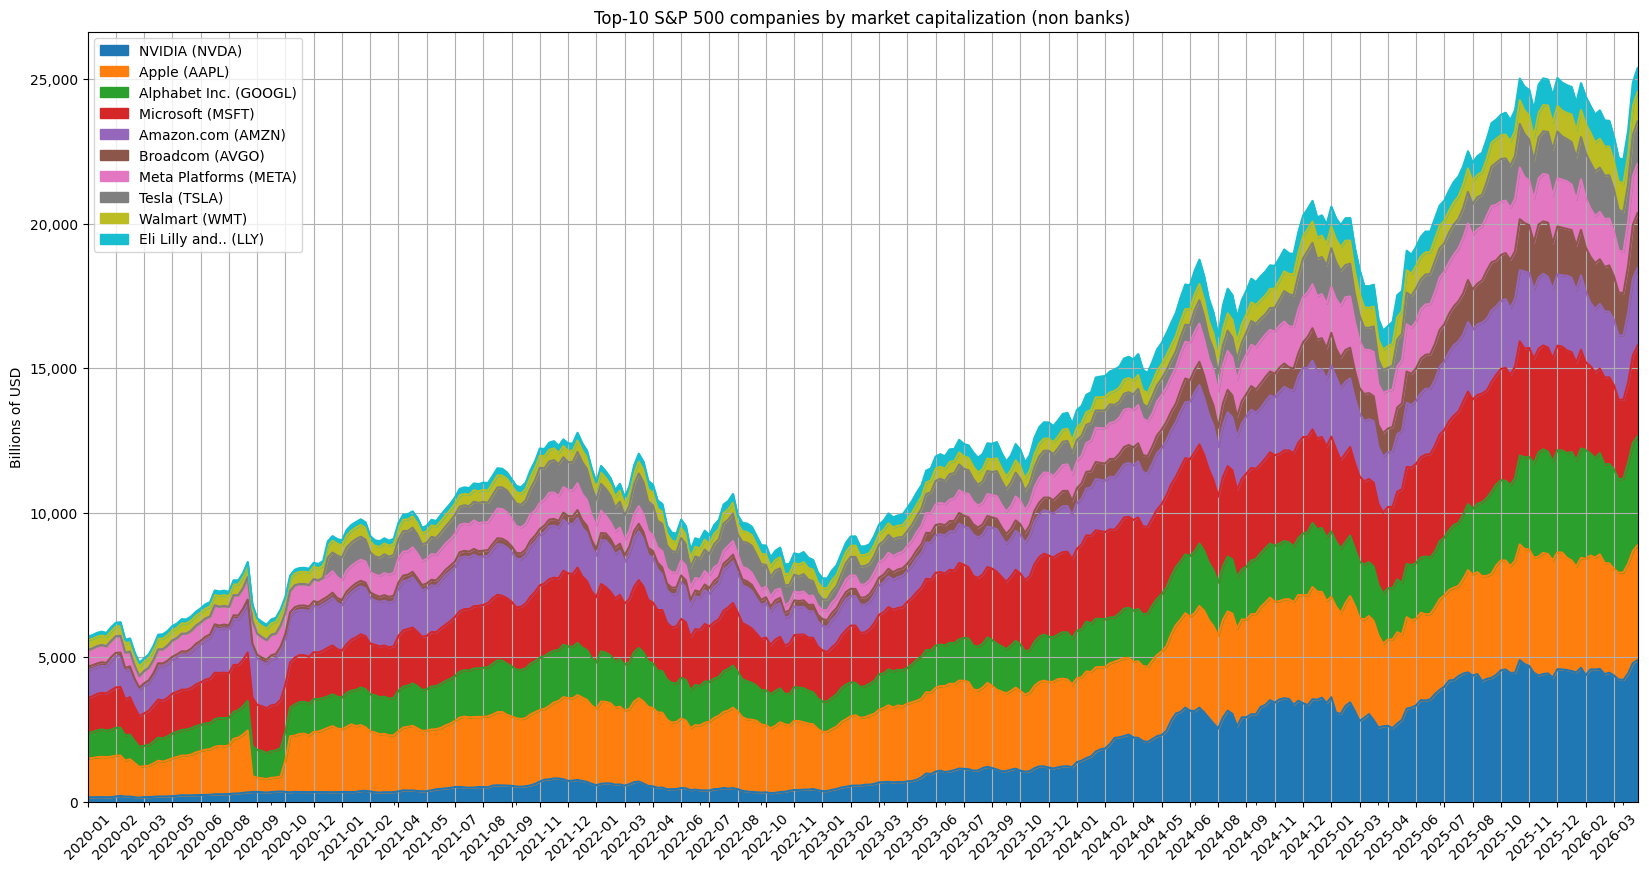

In [21]:
top10_weekly = top10_capitalization.loc[:, top10_capitalization.iloc[-1].sort_values(ascending=False).index]
ax = top10_weekly.plot.area(figsize=(20,10), grid=True, title=MKT_CAP_TOP10_SP500 + ' (non banks)',
                            xticks=top10_weekly.index[::6], xlabel='', rot=45,
                            ylabel=LEFT_Y_AXIS_LABEL)
ax.legend(ax.collections, top10_weekly.columns.map(lambda ticker: ticker_to_name[ticker] + f' ({ticker})'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: '{:,.0f}'.format(x/1e9)))
_ = ax.set_xticklabels(list(map('{:%Y-%m}'.format, top10_weekly.index[::6])))

In [22]:
fa_metrics = sp500_metrics.calculate_financial_metrics(list(top10_today.index)).dropna(thresh=2, subset=['ROE', 'Recurring ROE'])

#### Fundamentals sorted by the current market value added (MVA)

In [23]:
latest_mva = fa_metrics.groupby(level='symbol')['MVA'].last()
sorted_symbols = latest_mva.sort_values(ascending=False).index
fa_metrics.loc[sorted_symbols].iloc[:,:10]

Effective tax rate    ROIC Recurring ROIC     ROE Recurring ROE  \
symbol year                                                                    
NVDA   2023               0.00%  23.98%         16.97%  19.76%        13.64%   
       2024              12.00%  79.89%         79.89%  91.46%        91.46%   
       2025              13.26% 117.05%        117.05% 119.18%       119.18%   
       2026              15.12% 102.53%        102.53% 101.49%       101.49%   
AAPL   2022              16.20%  69.52%         69.52% 196.96%       196.96%   
       2023              14.72%  69.12%         69.12% 171.95%       171.95%   
       2024              24.09%  67.70%         67.70% 157.41%       157.41%   
       2025              15.61%  82.94%         82.94% 171.42%       171.42%   
MSFT   2022              13.11%  36.82%         36.97%  43.68%        43.85%   
       2023              18.98%  35.12%         35.12%  38.82%        38.82%   
       2024              18.23%  34.78%         34.61%  37.13%        36.94%   
       2025              17.63%  31.54%         31.43%  33.28%        33.16%   
AMZN   2022              18.59%  -0.50%         -8.81%  -1.86%       -10.93%   
       2023              18.59%  19.08%         19.57%  17.49%        17.98%   
       2024              18.59%  27.41%         26.74%  24.29%        23.68%   
       2025              18.59%  24.48%         28.32%  22.29%        25.86%   
AVGO   2022               7.55%  26.33%         25.91%  50.62%        49.70%   
       2023               6.72%  31.59%         31.15%  60.31%        59.38%   
       2024              37.80%   9.56%          8.46%  12.86%        10.77%   
       2025               0.00%  20.57%         20.09%  31.05%        30.23%   
META   2022              19.50%  19.09%         19.03%  18.45%        18.40%   
       2023              17.56%  31.12%         30.88%  28.04%        27.82%   
       2024              11.75%  41.88%         41.47%  37.14%        36.78%   
       2025              29.64%  29.92%         30.04%  30.24%        30.36%   
TSLA   2022               8.25%  40.26%         39.75%  27.42%        27.06%   
       2023               0.00%  36.27%         36.27%  27.39%        27.39%   
       2024              20.43%  12.63%         11.71%  10.39%         9.59%   
       2025              26.96%   5.78%          5.26%   4.85%         4.39%   
GOOGL  2022              15.92%  47.88%         43.53%  23.41%        21.28%   
       2023              13.91%  28.29%         27.41%  27.36%        26.50%   
       2024              16.44%  34.05%         34.64%  32.91%        33.48%   
       2025              16.78%  35.58%         41.04%  35.70%        41.22%   
LLY    2022               8.25%  26.25%         20.50%  57.95%        44.64%   
       2023              20.05%  19.34%          8.71%  48.43%        19.85%   
       2024              16.48%  28.86%         19.98%  84.26%        56.74%   
       2025              19.79%  38.79%         33.67% 101.16%        87.82%   
WMT    2023              33.64%  11.43%         11.43%  13.91%        13.91%   
       2024              25.53%  14.85%         14.85%  17.77%        17.77%   
       2025              23.38%  17.30%         17.30%  20.65%        20.65%   
       2026              24.43%  17.92%         17.92%  21.48%        21.48%   

             Cost of equity After tax cost of debt   WACC       EVA  \
symbol year                                                           
NVDA   2023          16.36%                  2.50% 16.02%   $1.54bn   
       2024          16.41%                  1.96% 16.30%  $23.87bn   
       2025          15.85%                  2.04% 15.80%  $63.23bn   
       2026          15.16%                  2.09% 15.12% $102.54bn   
AAPL   2022           9.60%                  3.71%  9.26%  $88.63bn   
       2023          11.01%                  2.75% 10.68%  $84.85bn   
       2024           9.53%                   <NA>  9.53%  $80.55bn   
       2025  

In [24]:
def display_roic_wacc_scatter_gather(df: pd.DataFrame, ticker_to_name: dict[str, str], num_years=4) -> None:
    # Calculate num_years-year averages per ticker (use all available years if < num_years)
    averages = df.groupby(level='symbol').tail(num_years).groupby(level='symbol').mean()
    # Latest MVA for bubble size
    latest_mva = df.groupby(level='symbol').last()[['MVA']]
    
    # Combine both
    plot_data = averages.iloc[:,:9].join(latest_mva, how='inner')
    
    plt.figure(figsize=(12, 8))
    ax = sns.scatterplot(data=plot_data, x='WACC', y='ROIC', hue=plot_data.index, size='MVA', sizes=(40, 600), alpha=0.85, legend=False)
    plt.axline((0, 0), slope=1, color='gray', linestyle='--', alpha=0.7, label='ROIC = WACC')
    
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    
    # === PROPERLY SCALED $1 TRILLION REFERENCE BUBBLE ===
    mva_min = plot_data['MVA'].min()
    mva_max = plot_data['MVA'].max()
    ref_mva = 1e12
    ref_size = 40 + (600 - 40) * (ref_mva - mva_min) / (mva_max - mva_min)
    
    # Create custom legend handles
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='$1 Trillion MVA',
               markerfacecolor='gray', markersize=14, alpha=0.35),
        Line2D([0], [0], color='gray', linestyle='--', label='ROIC = WACC')]
    
    plt.legend(handles=legend_elements, loc='upper left')
    
    for ticker, row in averages.iterrows():
        ax.text(row['WACC'] + 0.001, row['ROIC'], ticker_to_name[ticker], fontsize=9, ha='left', va='center')
    plt.title(f'{num_years}-Year Average ROIC vs {num_years}-Year Average WACC\n(bubble size = Latest MVA)')
    plt.xlabel("Average WACC")
    plt.ylabel("Average ROIC")
    plt.tight_layout()
    plt.grid(True, alpha=0.3)

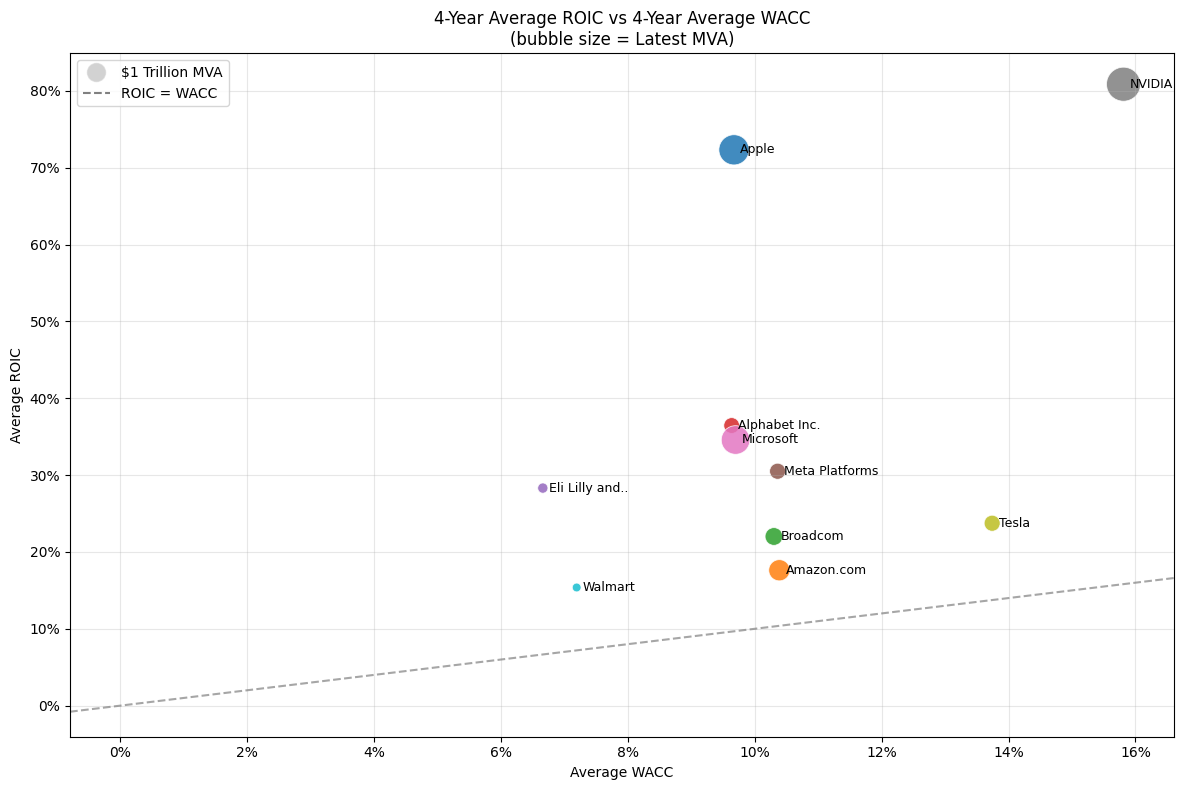

In [25]:
display_roic_wacc_scatter_gather(fa_metrics,ticker_to_name)

### Fundamental analysis for the S&P 500 companies from the Healthcare Sector
In this section I look at the fundamentals of the S&P 500 companies from the healthcare sector. I display them sorted by the latest market value added (MVA).

In [26]:
healthcare_sec = yfin.Sector('healthcare')
healthcare_tickers = set(healthcare_sec.top_companies.index) & set(sp500_metrics.get_current_components())

In [27]:
fa_healthcare_metrics = sp500_metrics.calculate_financial_metrics(list(healthcare_tickers)).dropna(thresh=2, subset=['ROE', 'Recurring ROE'])

In [28]:
latest_mva = fa_healthcare_metrics.groupby(level='symbol')['MVA'].last()
sorted_symbols = latest_mva.sort_values(ascending=False).index
fa_healthcare_metrics.loc[sorted_symbols].iloc[:40,:10]

Effective tax rate   ROIC Recurring ROIC     ROE Recurring ROE  \
symbol year                                                                   
LLY    2022               8.25% 26.25%         20.50%  57.95%        44.64%   
       2023              20.05% 19.34%          8.71%  48.43%        19.85%   
       2024              16.48% 28.86%         19.98%  84.26%        56.74%   
       2025              19.79% 38.79%         33.67% 101.16%        87.82%   
JNJ    2022              15.44% 17.55%         16.69%  23.36%        22.19%   
       2023              11.53% 39.86%         39.07%  48.29%        47.32%   
       2024              15.71% 18.35%         10.94%  20.06%        11.59%   
       2025              17.73% 28.49%         33.49%  35.03%        41.36%   
ABBV   2022              12.11% 19.33%         18.29%  68.47%        64.17%   
       2023              22.03% 10.28%          9.16%  35.13%        29.93%   
       2024               0.00% 11.62%          7.07%  62.18%        21.80%   
       2025              35.83%  9.81%          4.56% $0.00bn       $0.00bn   
ISRG   2022              16.33% 28.01%         28.01%  11.90%        11.90%   
       2023               7.23% 19.59%         19.59%  14.67%        14.67%   
       2024              12.58% 20.73%         20.73%  15.52%        15.52%   
       2025              13.13% 21.83%         21.83%  16.57%        16.57%   
MRK    2022              11.66% 23.99%         21.24%  31.52%        27.70%   
       2023              80.04%  0.91%          0.72%   0.87%         0.57%   
       2024              14.06% 26.76%         26.10%  40.75%        39.68%   
       2025              13.31% 24.65%         23.72%  36.86%        35.39%   
ABT    2022              16.53% 16.89%         16.89%  18.79%        18.78%   
       2023              14.12% 13.87%         13.79%  15.11%        15.02%   
       2024               0.00% 27.64%         27.69%  30.91%        30.97%   
       2025              22.94% 12.37%         12.44%  12.96%        13.04%   
UNH    2022              21.65% 18.04%         18.04%  23.30%        23.30%   
       2023              20.50% 19.45%         19.45%  24.16%        24.16%   
       2024              24.06% 11.97%          7.62%  14.30%         8.03%   
       2025              12.86% 10.03%          9.88%  11.80%        11.58%   
TMO    2022               8.97% 10.86%         10.50%  15.74%        15.18%   
       2023               4.51% 10.16%          9.49%  13.18%        12.12%   
       2024               9.34% 10.09%          9.65%  13.13%        12.46%   
       2025               7.48% 10.02%          9.62%  12.99%        12.37%   
AMGN   2022              10.81% 22.32%         22.32% 178.97%       178.97%   
       2023              14.49% 19.34%         19.34% 135.79%       135.79%   
       2024              11.26% 12.10%         12.10%  67.55%        67.55%   
       2025              14.09% 18.64%         18.64% 106.10%       106.10%   
GILD   2022              21.47% 12.98%          4.75%  21.65%         5.73%   
       2023              18.18% 15.57%         12.80%  25.77%        20.56%   
       2024              30.58%  2.98%        -13.49%   2.29%       -28.16%   
       2025              13.13% 24.75%         21.94%  40.66%        35.55%   

             Cost of equity After tax cost of debt   WACC      EVA       MVA  
symbol year                                                                   
LLY    2022           7.25%                  3.75%  7.09%  $4.78bn $322.67bn  
       2023           7.31%                  1.87%  7.07%  $3.57bn $520.10bn  
       2024           6.68%                  2.21%  6.47%  $8.72bn $649.62bn  
       2025           6.00%                   <NA>  6.00% $17.45bn $901.63bn  
JNJ    2022           6.38%                  1.18%  5.96% $12.00bn $358.29bn  
       2023           6.44%                  1.98%  6.11% $30.34bn $301.07bn  
       2024           5.81%                  1.93%  5.44% $10.

#### Displaying ROIC-WACC scatter-gather chart for the top 15 by MVA
Limiting it to firms with a positive ROIC for all years.

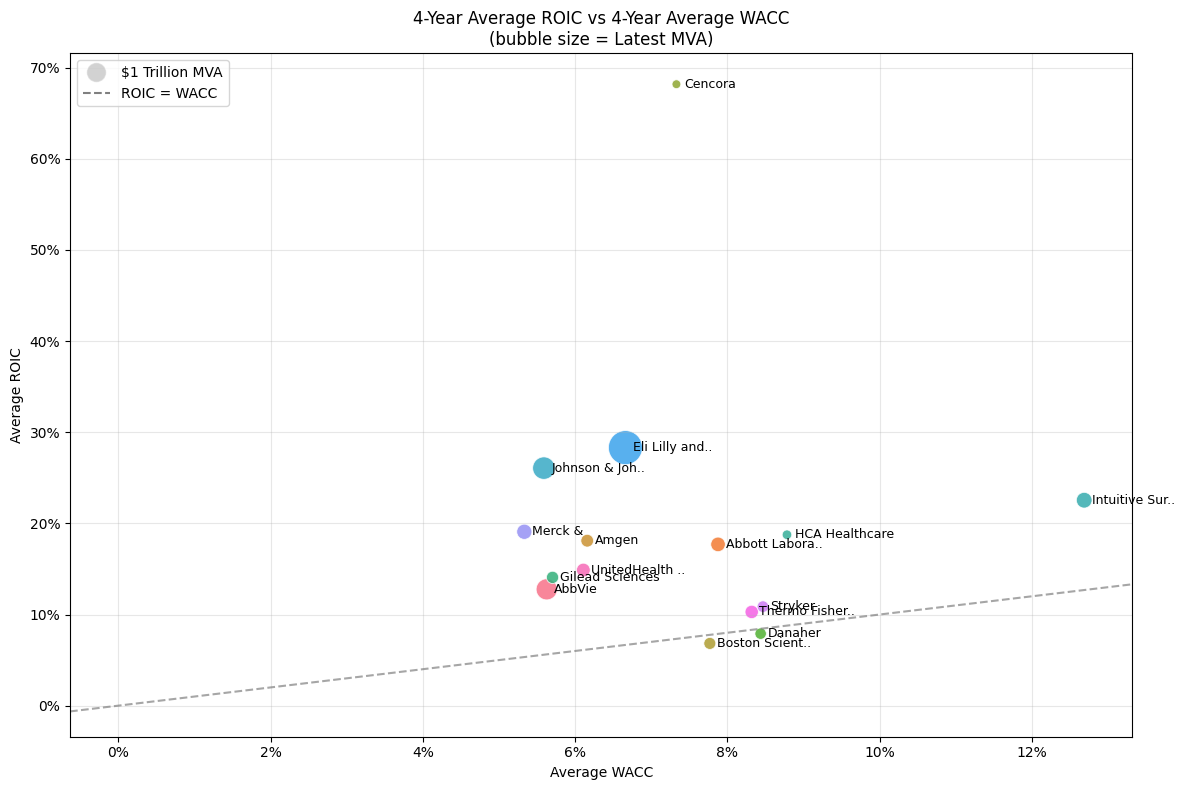

In [29]:
df_positive_roic = fa_healthcare_metrics[fa_healthcare_metrics.groupby(level='symbol')['ROIC'].transform(lambda x: (x >= 0).all())]
latest_mva = df_positive_roic.groupby(level='symbol')['MVA'].last()
sorted_symbols = latest_mva.sort_values(ascending=False).index
display_roic_wacc_scatter_gather(df_positive_roic.loc[sorted_symbols[:15]],
                                 dict(zip(healthcare_tickers, sp500_metrics.tickers_to_display_names(healthcare_tickers))))

### Fundamental analysis for the S&P 500 companies from the Energy Sector
In this section I look at the fundamentals of the S&P 500 companies from the Energy sector.

In [30]:
energy_sec = yfin.Sector('energy')
energy_tickers = set(energy_sec.top_companies.index) & set(sp500_metrics.get_current_components())

In [31]:
fa_energy_metrics = sp500_metrics.calculate_financial_metrics(list(energy_tickers)).dropna(thresh=2, subset=['ROE', 'Recurring ROE'])

In [32]:
latest_mva = fa_energy_metrics.groupby(level='symbol')['MVA'].last()
sorted_symbols = latest_mva.sort_values(ascending=False).index
fa_energy_metrics.loc[sorted_symbols].iloc[:40,:10]

Effective tax rate    ROIC Recurring ROIC    ROE Recurring ROE  \
symbol year                                                                   
XOM    2022              25.95%  26.73%         26.73% 27.53%        27.53%   
       2023              29.23%  17.05%         17.05% 17.35%        17.35%   
       2024              28.26%  13.65%         13.65% 13.94%        13.94%   
       2025              27.88%  10.12%         10.12% 10.74%        10.74%   
CVX    2022              28.32%  21.66%         21.66% 22.13%        22.13%   
       2023              27.63%  12.79%         12.79% 13.27%        13.27%   
       2024              35.47%  10.48%         10.48% 11.21%        11.21%   
       2025              36.76%   6.61%          6.61%  7.12%         7.12%   
COP    2022              33.82%  34.08%         35.75% 38.91%        40.90%   
       2023              32.73%  19.73%         19.87% 22.53%        22.69%   
       2024              32.38%  13.88%         13.90% 16.21%        16.23%   
       2025              36.88%  10.74%         11.28% 12.36%        13.04%   
WMB    2022              16.72%   8.16%          8.17% 14.59%        14.59%   
       2023              22.81%  10.88%         12.27% 21.97%        25.61%   
       2024              21.43%   8.15%          8.69% 14.97%        16.43%   
       2025              23.64%   8.65%          8.28% 17.55%        16.47%   
BKR    2022             100.00%  -3.21%         -3.21% -4.14%        -4.14%   
       2023              25.80%  11.19%         12.07% 12.93%        14.04%   
       2024               7.87%  16.38%         16.86% 18.29%        18.86%   
       2025               8.79%  13.58%         11.69% 14.35%        12.20%   
EOG    2022              21.63%  33.37%         19.17% 31.31%        17.75%   
       2023              21.62%  30.76%         32.98% 28.73%        30.84%   
       2024              22.09%  24.42%         23.92% 22.29%        21.83%   
       2025              21.72%  16.90%         14.68% 16.83%        14.54%   
SLB    2022              18.24%  13.45%         14.44% 19.13%        20.71%   
       2023              19.06%  15.63%         15.61% 21.36%        21.33%   
       2024              19.27%  15.90%         14.59% 20.41%        18.57%   
       2025              19.58%  11.45%          9.18% 13.59%        10.54%   
TRGP   2022               7.92%   9.99%         12.49% 24.00%        32.05%   
       2023              18.70%  11.47%         11.47% 28.06%        28.06%   
       2024              19.84%  10.93%         10.93% 29.06%        29.06%   
       2025              21.30%  13.56%         13.56% 50.50%        50.50%   
TPL    2022              21.53% 170.92%        170.92% 57.75%        57.75%   
       2023              21.62% 146.80%        146.80% 44.67%        44.67%   
       2024              21.57%  88.55%         88.55% 41.73%        41.73%   
       2025              21.13%  46.04%         46.04% 37.15%        37.15%   
VLO    2022              22.39%  37.11%         36.96% 45.26%        45.08%   
       2023              22.26%  27.80%         27.80% 32.73%        32.73%   
       2024              18.71%   9.48%          9.48%  9.88%         9.88%   
       2025              25.26%   8.39%          5.82%  8.68%         5.55%   

             Cost of equity After tax cost of debt  WACC      EVA       MVA  
symbol year                                                                  
XOM    2022           6.17%                  2.87% 5.90% $43.91bn $243.52bn  
       2023           6.23%                  1.45% 5.78% $24.20bn $180.86bn  
       2024           5.60%                  1.72% 5.29% $21.07bn $187.44bn  
       2025           4.92%                  1.02% 4.61% $15.93bn $219.87bn  
CVX    2022           7.66%                  1.58% 7.28% $23.79bn $181.61bn  
       2023           7.72%                  1.54% 7.30%  $9.32bn $107.62bn  
       2024           7.09%                  1.69% 6.63%  $6.64bn  $87

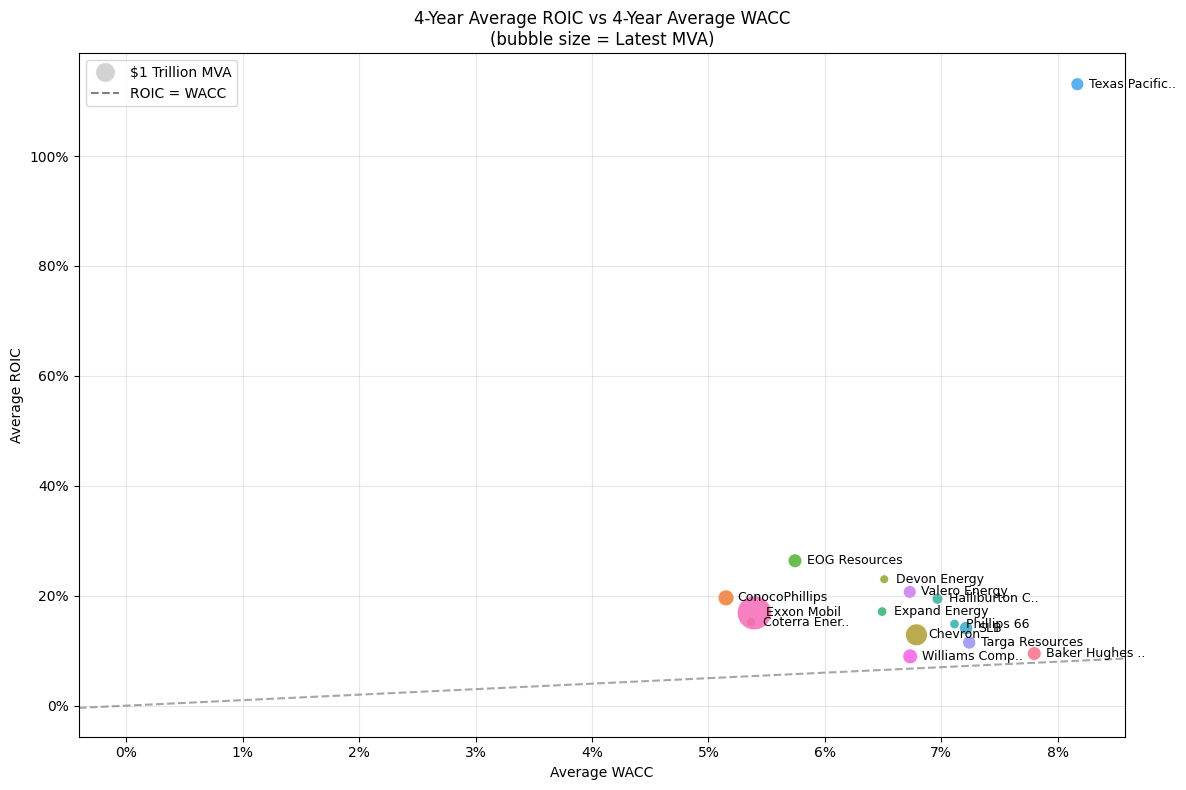

In [33]:
display_roic_wacc_scatter_gather(fa_energy_metrics.loc[sorted_symbols[:15]],
                                 dict(zip(energy_tickers, sp500_metrics.tickers_to_display_names(energy_tickers))))

### Fundamental analysis for the S&P 500 companies from the Communication Services
In this section I look at the fundamentals of the S&P 500 companies from the Communication Services sector.

In [34]:
comms_sec = yfin.Sector('communication-services')
comms_tickers = set(comms_sec.top_companies.index) & set(sp500_metrics.get_current_components())

In [35]:
fa_comms_metrics = sp500_metrics.calculate_financial_metrics(list(comms_tickers)).dropna(thresh=2, subset=['ROE', 'Recurring ROE'])

In [36]:
latest_mva = fa_comms_metrics.groupby(level='symbol')['MVA'].last()
sorted_symbols = latest_mva.sort_values(ascending=False).index
fa_comms_metrics.loc[sorted_symbols].iloc[:40,:10]

Effective tax rate    ROIC Recurring ROIC      ROE Recurring ROE  \
symbol year                                                                     
META   2022              19.50%  19.09%         19.03%   18.45%        18.40%   
       2023              17.56%  31.12%         30.88%   28.04%        27.82%   
       2024              11.75%  41.88%         41.47%   37.14%        36.78%   
       2025              29.64%  29.92%         30.04%   30.24%        30.36%   
GOOG   2022              15.92%  47.88%         43.53%   23.41%        21.28%   
       2023              13.91%  28.29%         27.41%   27.36%        26.50%   
       2024              16.44%  34.05%         34.64%   32.91%        33.48%   
       2025              16.78%  35.58%         41.04%   35.70%        41.22%   
NFLX   2022              14.67%  33.21%         33.21%   21.62%        21.62%   
       2023              12.85%  20.90%         20.90%   26.15%        26.15%   
       2024              12.58%  30.86%         30.86%   38.43%        38.43%   
       2025              13.69%  36.09%         36.09%   42.76%        42.76%   
APP    2022               5.96%  -1.53%         -1.53%  -10.13%       -10.13%   
       2023               8.73%  15.35%         15.35%   22.62%        22.62%   
       2024               1.39%  48.67%         48.67%  134.67%       134.67%   
       2025              13.15%  99.50%         99.50%  206.78%       206.78%   
TMUS   2022              17.67%   3.91%          2.97%    3.72%         1.87%   
       2023              24.38%   7.98%          7.99%   12.38%        12.41%   
       2024              22.93%  10.38%         10.38%   17.93%        17.93%   
       2025              23.03%  10.13%          9.97%   18.18%        17.82%   
DIS    2022              32.77%   2.88%          2.47%    2.90%         2.34%   
       2023              28.92%   2.59%          0.72%    2.13%        -0.33%   
       2024              23.73%   4.51%          2.59%    4.55%         2.00%   
       2025               0.00%   9.60%          9.04%   11.27%        10.53%   
TTWO   2022              10.18%  18.90%         18.82%   10.97%        10.92%   
       2023              15.95% -14.74%        -15.69%  -17.50%       -18.51%   
       2024               0.00% -37.36%        -63.11%  -50.91%       -84.68%   
       2025               0.28% -69.86%       -129.36% -114.76%      -208.82%   
EA     2022              27.01%  12.13%         12.12%   10.35%        10.34%   
       2023              39.52%  12.25%         11.28%   10.75%         9.87%   
       2024              19.89%  19.73%         19.01%   17.20%        16.55%   
       2025              30.16%  18.30%         17.85%   16.13%        15.72%   
LYV    2022              23.64%  45.17%         47.48%   34.89%        38.10%   
       2023              22.94%  58.35%         58.10%   51.20%        50.87%   
       2024               0.00%  60.19%         60.61%   53.39%        53.90%   
       2025              32.97%  27.16%         27.62%   26.35%        26.98%   
TTD    2022              58.09%   4.36%          4.39%    2.52%         2.54%   
       2023              33.23%  15.76%         15.72%    8.36%         8.33%   
       2024              22.52%  26.74%         26.80%   15.37%        15.41%   
       2025              32.71%  23.57%         23.59%   16.32%        16.34%   

             Cost of equity After tax cost of debt   WACC       EVA  \
symbol year                                                           
META   2022          11.27%                  1.12% 10.50%  $10.51bn   
       2023          11.33%                  1.15% 10.93%  $25.60bn   
       2024          10.71%                  1.46% 10.41%  $47.34bn   
       2025          10.02%                  1.23%  9.60%  $41.61bn   
GOOG   2022          10.37%                  1.88%  9.92%  $47.78bn   
       2023          10.43%                  0.93% 10.12%  $47.57bn   
       2024           9.80%               

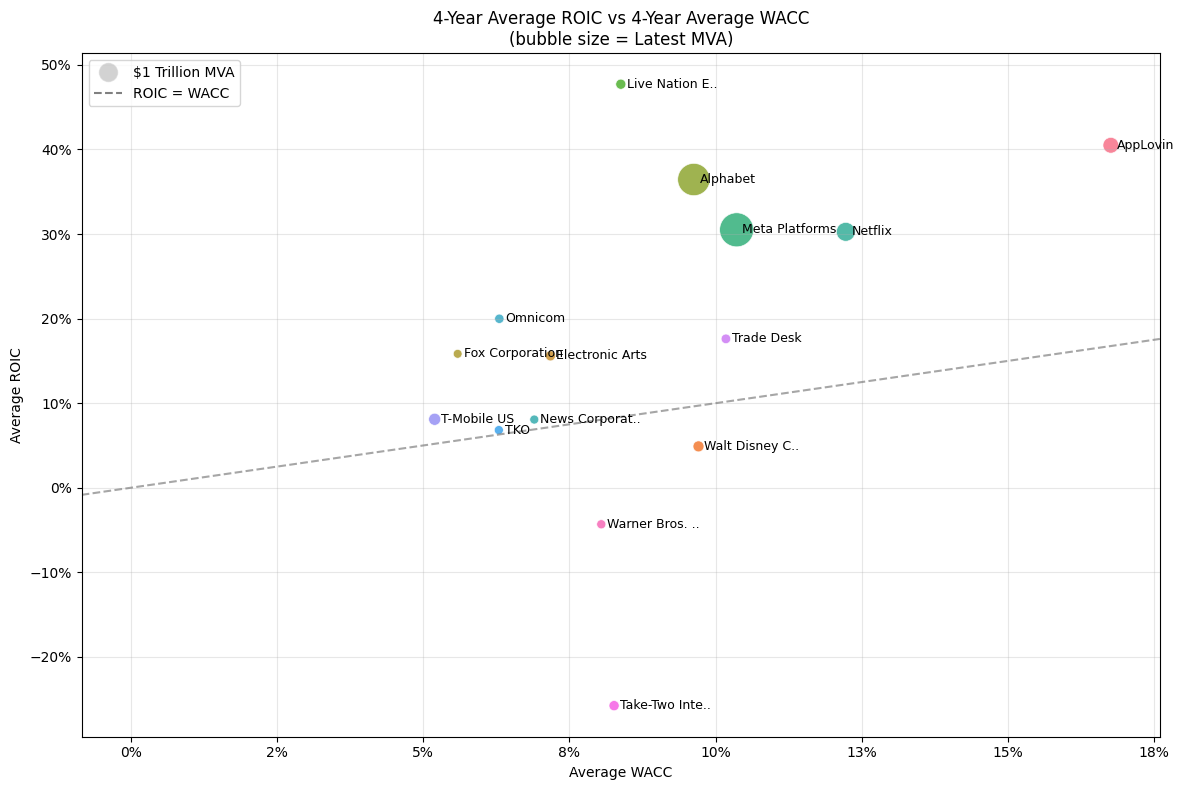

In [37]:
display_roic_wacc_scatter_gather(fa_comms_metrics.loc[sorted_symbols[:15]],
                                 dict(zip(comms_tickers, sp500_metrics.tickers_to_display_names(comms_tickers))))

## S&P 500 companies from the banking sector
One of the most frequently used tools for analyzing banks is their P/B and ROE ratios. Being traditional businesses for which book value is a meaningful metric, the following equation holds for banks:
$$\frac{P}{B}=\frac{ROE}{\text{Cost-of-equity} - g}$$
where:
* `P` is the market price of a bank's equity
* `B` is the book value of the bank's equity
* `ROE` is its return on equity
* `g` is an expected nominal growth of the bank's earnings, the formula assumes that banks grow thair capital at the rate of earnings' growth, see [this blog post by Aswath Damodaran for details](https://aswathdamodaran.blogspot.com/2023/05/good-bad-banks-and-good-bad-investments.html).

Therefore, a popular way to compare banks is to plot their P/B (price-to-book) ratios against their ROEs (return on equity). Banks whose ROE exceeds their cost of equity tend to have a P/B ratio greater than 1. If the cost of equity and earnings growth were the same for all banks, the points on this graph would form a line. However, since the cost of equity and earnings prospects differ slightly among financial institutions, this is not the case. Still, for banks that are part of the S&P 500, the points are fairly close, implying they have a similar cost of equity. Their approximate cost of equity can be derived from the above equation.

In the remainder of this notebook I will plot this for US Banks that are part of the S&P 500 index and derive their approximate cost of equity. As an approximation of `g`, I will use annualized _nominal_ GDP growth rate from the last quarter (alternatively I could use a year-on-year _nominal_ GDP growth rate from the last quarter). While incorrect for an individual bank, it is approximately correct as an average for the banking industry. I use P/B values based on the book value as reported in the most recent quarter (MRQ) and ROE based on the trailing twelve months (TTM).

I plot a linear regression line that shows a linear dependency between ROE and P/B values for the banks in the sample. The bigger the slope of the regression line, the smaller the cost of equity.

To identify banks, I focus on companies within the `Financial Services` sector, specifically those classified in one of the following industries:
* Banks - Diversified
* Banks - Regional
* Capital Markets

In [41]:
import scipy
banking_sector_companies = sp500_metrics.get_banking_sector_components()
roe_pb = sp500_metrics.get_roe_and_pb(banking_sector_companies).dropna()
slope, intercept, rvalue, pvalue = scipy.stats.linregress(roe_pb.iloc[:,0].to_list(),
                                                          roe_pb.iloc[:,1].to_list())[0:4]

gdp = web.get_data_fred('GDP', start=start).GDP

# Uncomment the below if you want to use an annulized GDP growth from the last quarter instead of its year-on-year growth.
gdp_annualized = (gdp/gdp.shift(1)).pow(4) - 1

# Uncomment the below if you want to use a year-over-year nominal GDP growth rate
# gdp_annualized = gdp.rolling(4).mean().pct_change(4, fill_method=None)

g = gdp_annualized.iloc[-1]
names = sp500_metrics.tickers_to_display_names(banking_sector_companies)
ticker_to_name = dict(zip(banking_sector_companies, names))

In [102]:
def display_roe_pb(roe_pb_df, roe_cutoff=None, pb_cutoff=None, 
                   slope_intercept_r_p_value=None, expand_tickers=True):
    """
    Plots Price-to-Book vs ROE for US Banks with clean seaborn styling.
    """
    assert not (bool(roe_cutoff) ^ bool(pb_cutoff)), 'Either both cutoff values or none'

    if roe_cutoff:
        roe_cutoff_min, roe_cutoff_max = roe_cutoff
        roe_pb_df = roe_pb_df.loc[(roe_pb_df.ROE < roe_cutoff_max) & (roe_pb_df.ROE > roe_cutoff_min) & (roe_pb_df['P/B'] < pb_cutoff)]

    slope, intercept, rvalue, pvalue = slope_intercept_r_p_value if slope_intercept_r_p_value else \
                    scipy.stats.linregress(roe_pb_df.iloc[:,0].to_list(), roe_pb_df.iloc[:,1].to_list())[0:4]

    # Reset index for seaborn
    plot_df = roe_pb_df.reset_index()
    ticker_col = plot_df.columns[0]

    # === PLOT WITH SEABORN ===
    plt.figure(figsize=(15, 10))
    ax = sns.scatterplot(
        data=plot_df,
        x=plot_df.columns[1],      # ROE
        y=plot_df.columns[2],      # P/B
        hue=ticker_col,
        palette='tab10',
        s=140,
        alpha=0.9,
        edgecolor='black',
        linewidth=0.6,
        legend=False               # ← Legend removed as requested
    )

    # Regression line
    x_vals = np.array([roe_pb_df.iloc[:, 0].min(), roe_pb_df.iloc[:, 0].max()])
    plt.plot(x_vals, intercept + slope * x_vals, 
             color='black', linestyle='--', linewidth=1.5, label='Regression line')

    # Ticker labels directly on the plot
    for ticker, (roe, pb) in roe_pb_df.iterrows():
        name = ticker_to_name.get(ticker, ticker) if expand_tickers else ticker
        plt.text(roe + 0.002, pb, name, fontsize=10, ha='left', va='bottom', alpha=0.95)

    # Formatting
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
    
    # Stats box
    stats_text = (f'Slope = {slope/100:.3f}\n'
                  f'R² = {rvalue**2:.3f}\n'
                  f'p-value = {pvalue:.2g}')
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5", 
                                               facecolor="white", alpha=0.95, edgecolor="gray"))

    # Titles and labels
    title = 'Price to Book vs ROE of US Banks'
    if roe_cutoff:
        title += f' (subset: {roe_cutoff_min:.0%} < ROE < {roe_cutoff_max:.0%} and P/B < {pb_cutoff})'
    title += f' on {sp500_metrics.capitalization.index[-1]:%Y-%m-%d}'
    
    plt.title(title)
    plt.xlabel(roe_pb_df.columns[0] + " (ttm)")
    plt.ylabel(roe_pb_df.columns[1] + " (mrq)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    return roe_pb_df, slope, intercept, rvalue, pvalue

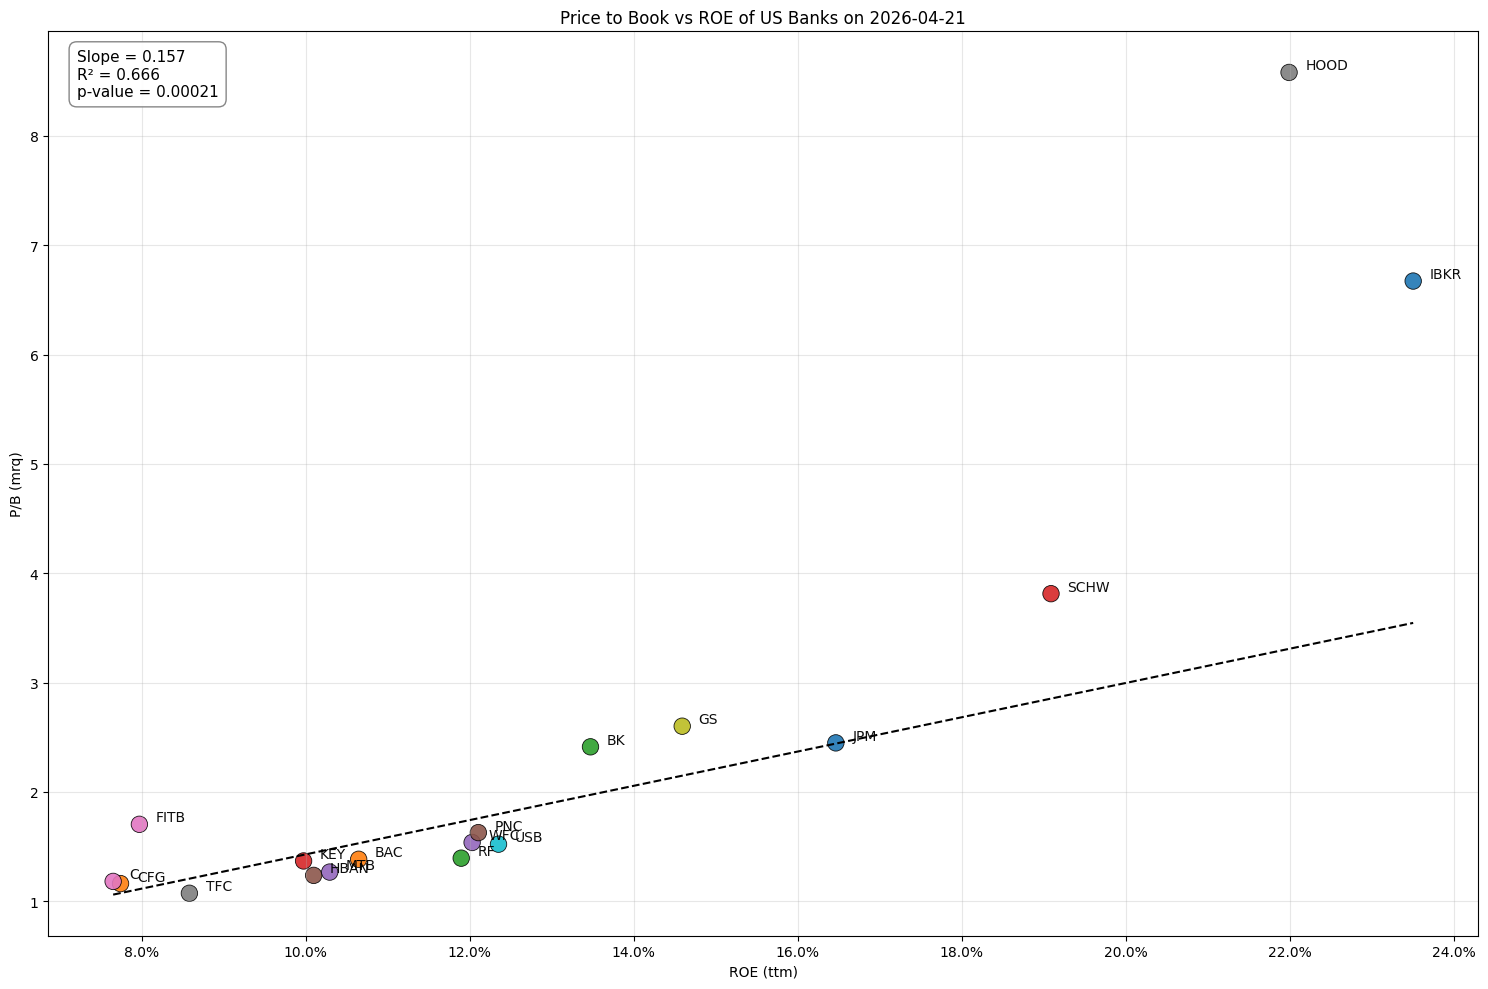

In [103]:
_ = display_roe_pb(roe_pb, slope_intercept_r_p_value=(slope, intercept, rvalue, pvalue), expand_tickers=False)

In [104]:
print_cost_of_equity(roe_pb, slope, g)

The sensitivity of P/B to ROE for US banks: 0.16
This means that for every percentage point improvement in ROE, the bank's P/B increases by 0.16

From the above equation it also means that an approximate cost of equity for these banks is: 10.62%
['IBKR', 'CFG', 'BK', 'KEY', 'WFC', 'HBAN', 'C', 'HOOD', 'GS', 'USB', 'JPM', 'BAC', 'RF', 'SCHW', 'MTB', 'PNC', 'FITB', 'TFC']


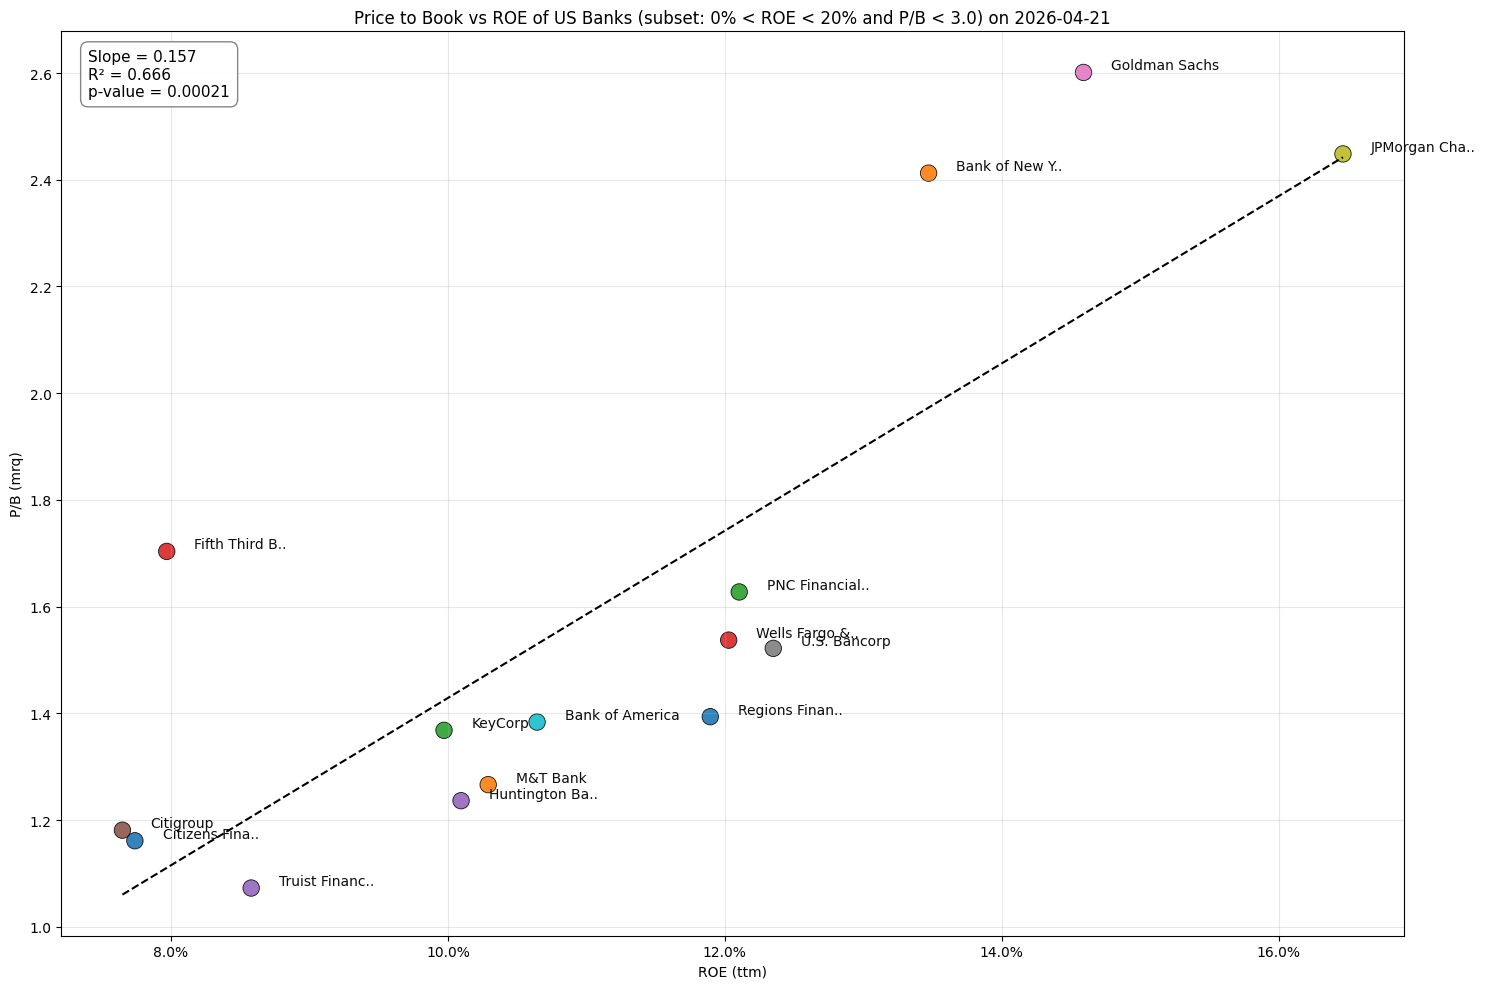

In [105]:
# Define the subset to zoom into
roe_cutoff = (0, .2)
pb_cutoff = 3.

# Reusing linear regression data from the whole set of banks
# roe_pb_subset, _, _, _, _ = display_roe_pb(roe_pb, roe_cutoff, pb_cutoff, (slope, intercept, rvalue, pvalue))

# Uncomment if you want to recalculate linear regression for the subset
roe_pb_subset, slope, intercept, rvalue, pvalue = display_roe_pb(roe_pb, roe_cutoff, pb_cutoff)

In [106]:
print_cost_of_equity(roe_pb_subset, slope, g)

The sensitivity of P/B to ROE for US banks: 0.16
This means that for every percentage point improvement in ROE, the bank's P/B increases by 0.16

From the above equation it also means that an approximate cost of equity for these banks is: 10.62%
['CFG', 'BK', 'KEY', 'WFC', 'HBAN', 'C', 'GS', 'USB', 'JPM', 'BAC', 'RF', 'MTB', 'PNC', 'FITB', 'TFC']
